In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
from belief_dynamics_learning.world2d import World2D
from belief_dynamics_learning.dpf import *
from belief_dynamics_learning.dpf_utils import *

%load_ext autoreload
%autoreload 2

Example demonstration of 2D world, belief of the object pose, and robot trajectory in the 2D world.

In [2]:
num_particles = 100
dt = 0.1

# object properties 
dim_object = np.array([0.067, 0.14])
qo_gt = np.array([0, 1, 0]) # ground truth object pose
sigma_pos = 0.06 # standard deviation of position noise

# robot properties
qr_0 = np.array([0, 0.7])
r_robot = 0.05


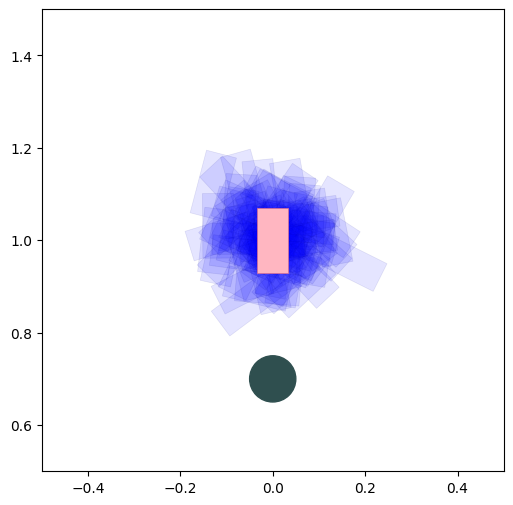

In [3]:
world = World2D(num_particles, qo_gt, dim_object, sigma_pos, 
                qr_0, r_robot, dt)
world.plot_belief()

In [4]:
world.sample_gt_object_pose()
world.sample_robot_pose()
q_r_hist, o_hist, a_hist = world.rollout(100, world.qo_gt.copy())

# only keep bits of sequence around positive contact measurements
contact_idx = np.where(o_hist==1)[0]
if len(contact_idx) == 0:
    print('No contact detected')
else:
    min_idx = np.min(contact_idx)
    max_idx = np.max(contact_idx)
    buffer_lb = np.min([min_idx, 10])
    buffer_ub = np.min([len(o_hist)-max_idx, 10])
    keep_idx = [min_idx-buffer_lb, max_idx+buffer_ub]
    print('Keeping indices:', keep_idx)
    q_r_hist = q_r_hist[keep_idx[0]:keep_idx[1]]
    o_hist = o_hist[keep_idx[0]:keep_idx[1]]
    world.plot_rollout(q_r_hist, o_hist)

No contact detected


Differentiable particle filter

In [5]:
# initialise hyperparameters for the differentiable particle filter (DPF)
propose_ratio = 0.7
proposer_keep_ratio = 0.15 # what it was set to initially and from the paper code
min_obs_likelihood = 0.004

# initialise hyperparameters for the DPF training
split_ratio = 0.8
seq_len = 2
batch_size = 20
num_epochs_pp = 150
num_epochs_ole = 250
patience = 10
learning_rate = 0.0003
dropout_keep_ratio = 0.3
num_particles = 100
particle_std = 0.2
contact_only = True
xy_only = False
phi_dataset = True

# create instance of DPF class
dpf = DPF(propose_ratio, proposer_keep_ratio, min_obs_likelihood, num_particles, world, xy_only, phi_dataset)

Using device: cpu


In [6]:
# find file path to the training data
root = os.getcwd()
save_path = os.path.join(root, '../data/phi_data_min_1_contacts_seq_len_2_test_500_trajectories.pkl')

# ensure the training data file exists before attempting to load it
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        raw_data = pickle.load(f)
else:
    print("File not found:", save_path)

Organise data into a dictionary

Object pose data: (500, 1, 3)
Robot pose data: (500, 1, 2)
q_o_r data: (500, 1, 2)
Phi observation data: (500, 2, 1)
Closest point data: (500, 2, 2)
Object pose (example trajectory): [[0.26895363 1.3940732  0.3847629 ]]
Robot pose (example trajectory): [0.22784656 1.28226427]
q_o_r data (example trajectory): [0.04110707 0.11180893]
Phi observation (example trajectory): [0.70377013]
Closest point (example trajectory): [0.03665559 0.04318754]


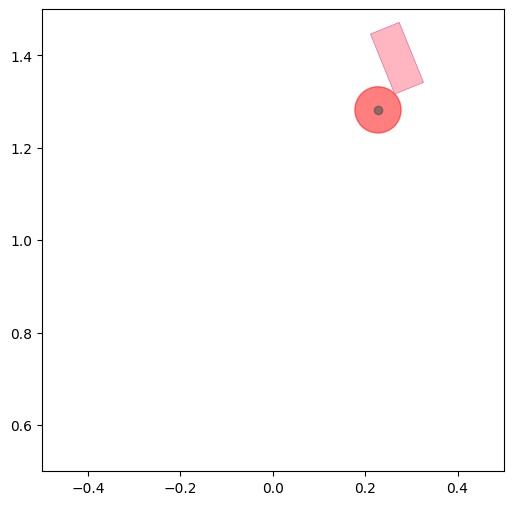

In [7]:
# data generation parameters
num_sequences = 500
num_steps_per_sequence = seq_len

data = organise_data(raw_data, num_sequences, num_steps_per_sequence, contact_only, xy_only)
    
# verify shapes of matrices containing 
print('Object pose data:', data['q_o'].shape)
print('Robot pose data:', data['q_r'].shape)
print('q_o_r data:', data['q_o_r'].shape)
print('Phi observation data:', data['phi'].shape)
print('Closest point data:', data['cp'].shape)

# plot example trajectory from the dataset
traj = np.random.randint(0, num_sequences)
print('Object pose (example trajectory):', data['q_o'][traj, :, :])
print('Robot pose (example trajectory):', data['q_r'][traj, 0, :])
print('q_o_r data (example trajectory):', data['q_o_r'][traj, 0, :])
print('Phi observation (example trajectory):', data['phi'][traj, 0, :])
print('Closest point (example trajectory):', data['cp'][traj, 0, :])
world.qo_gt = data['q_o'][traj, 0, :]
world.plot_rollout(data['q_r'][traj, :, :], 1)
# world.plot_rollout(data['q_r'][traj, :, :], data['o'][traj, :, :])

In [8]:
# noisify data
data = noisify_data(data)

In [9]:
# compute some statistics aboout the data
means, stds, q_o_r_maxs, q_o_r_mins, q_r_step_sizes, q_r_maxs, q_r_mins = compute_statistics(data, phi_dataset)
print('q_o_r_mins:', q_o_r_mins)

q_o_r_mins: [-0.12759081 -0.12605006]


/opt/anaconda3/envs/summer-proj/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/summer-proj/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
# # create dataset and dataloader for training and validation
# train_dataset = TrajectoriesDataset(train_data, seq_len)
# val_dataset = TrajectoriesDataset(val_data, seq_len)

# train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

# # test the dataloader
# for batch in train_dataloader:
#     print(batch['q_o'].shape)  # Expected shape: [20, 1, 3]
#     print(batch['q_r'].shape)  # Expected shape: [20, 100, 2]
#     print(batch['q_o_r'].shape) # Expected shape: [20, 100, 1]
#     print(batch['phi'].shape)    # Expected shape: [20, 100, 2]
#     break

Before training:

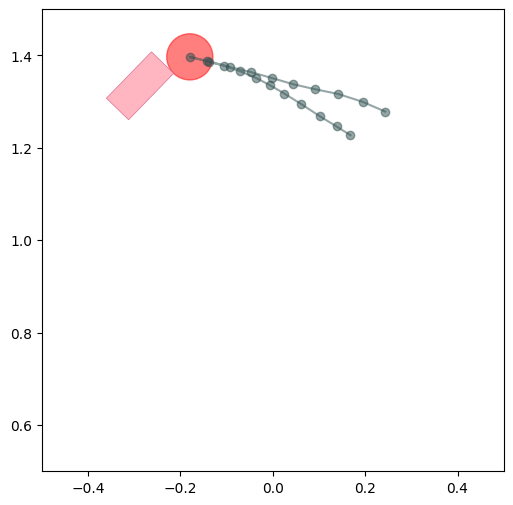

Desired robot position during contact event: tensor([[-0.1813,  1.3952]], dtype=torch.float64)
Achieved robot position during contact event: tensor([[-0.1795,  1.3970]], dtype=torch.float64)
Phi during contact event: tensor([[-2.3683]], dtype=torch.float64)


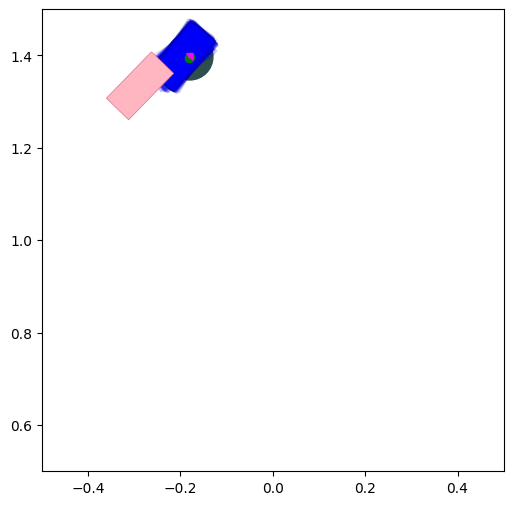

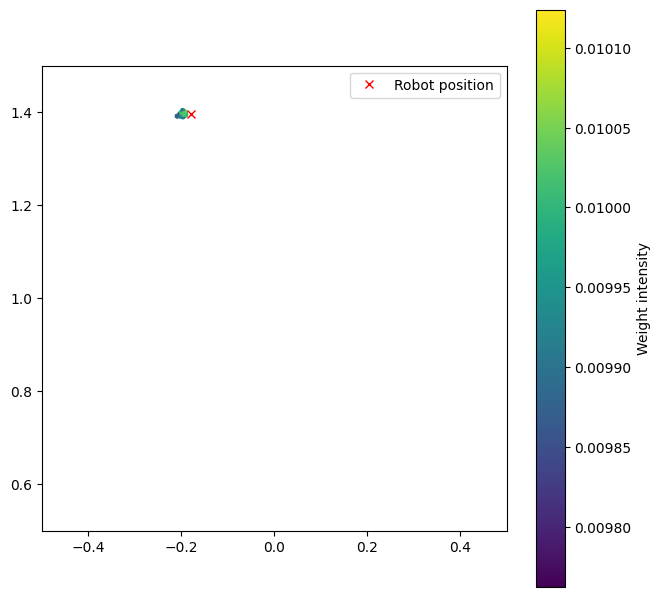

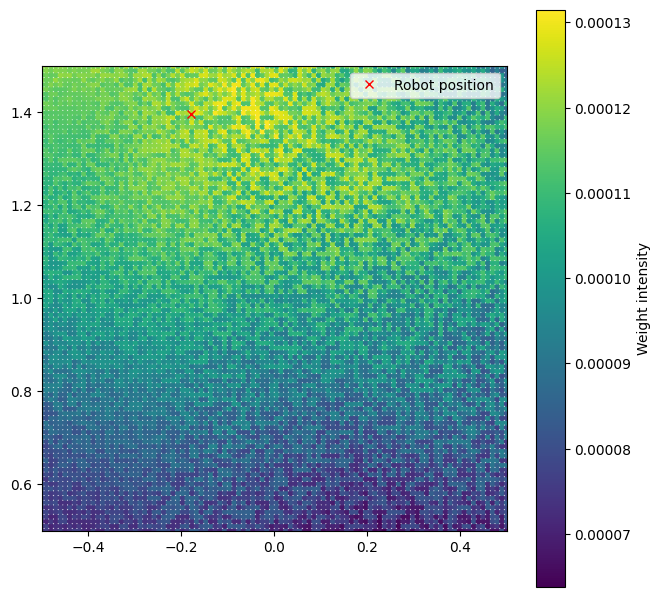

In [11]:
dpf.test(q_o_r_mins, q_o_r_maxs, means, stds, xy_only)

Epoch 1/150
Epoch 2/150
Epoch 3/150
Epoch 4/150
Epoch 5/150
Epoch 6/150
Epoch 7/150
Epoch 8/150
Epoch 9/150
Epoch 10/150
Epoch 11/150
Epoch 12/150
Epoch 13/150
Epoch 14/150
Epoch 15/150
Epoch 16/150
Epoch 17/150
Epoch 18/150
Epoch 19/150
Epoch 20/150
Epoch 21/150
Epoch 22/150
Epoch 23/150
Epoch 24/150
Epoch 25/150
Epoch 26/150
Epoch 27/150
Epoch 28/150
Epoch 29/150
Epoch 30/150
Epoch 31/150
Epoch 32/150
Epoch 33/150
Epoch 34/150
Epoch 35/150
Epoch 36/150
Epoch 37/150
Epoch 38/150
Epoch 39/150
Epoch 40/150
Epoch 41/150
Epoch 42/150
Epoch 43/150
Epoch 44/150
Epoch 45/150
Epoch 46/150
Epoch 47/150
Epoch 48/150
Epoch 49/150
Epoch 50/150
Epoch 51/150
Epoch 52/150
Epoch 53/150
Epoch 54/150
Epoch 55/150
Epoch 56/150
Epoch 57/150
Epoch 58/150
Epoch 59/150
Epoch 60/150
Epoch 61/150
Epoch 62/150
Epoch 63/150
Epoch 64/150
Epoch 65/150
Epoch 66/150
Epoch 67/150
Epoch 68/150
Epoch 69/150
Epoch 70/150
Epoch 71/150
Epoch 72/150
Epoch 73/150
Epoch 74/150
Epoch 75/150
Epoch 76/150
Epoch 77/150
Epoch 78

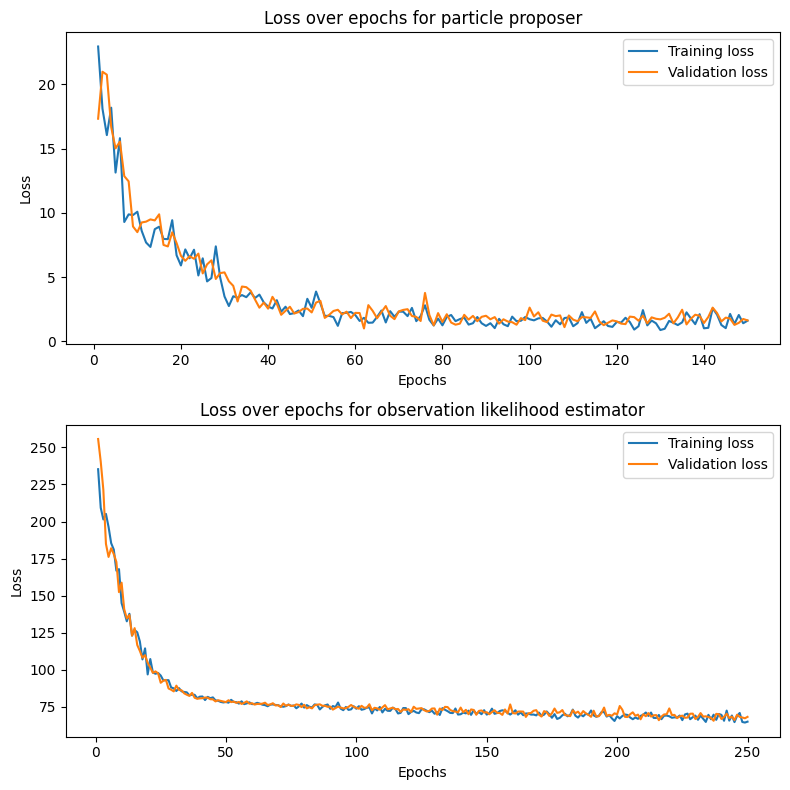

In [12]:
if contact_only == True:
    seq_len = 1

# train the dpf and extract the last batch from training
dpf.fit(data, split_ratio, batch_size, seq_len, num_epochs_pp, num_epochs_ole, learning_rate, num_particles, xy_only, phi_dataset)

# q_o, particle_list, particle_prob_list = dpf.fit(data, split_ratio, batch_size, seq_len, num_epochs_pp, patience, learning_rate, num_particles, xy_only, phi_dataset) # form GMM plots

After training:

In [13]:
# # plot GMM
# dpf.plot_GMM(q_o, particle_list, particle_prob_list, xy_only)

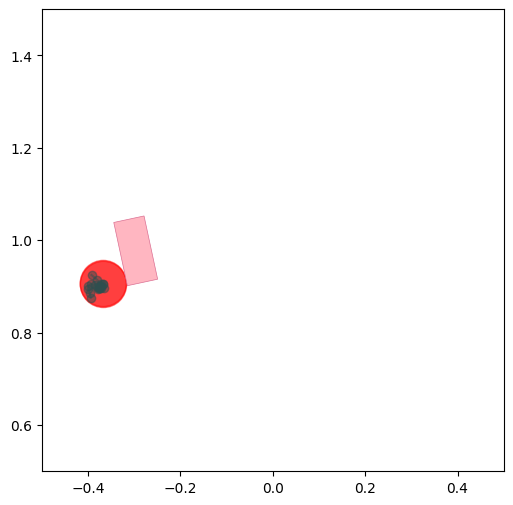

Desired robot position during contact event: tensor([[-0.3656,  0.9067]], dtype=torch.float64)
Achieved robot position during contact event: tensor([[-0.3668,  0.9064]], dtype=torch.float64)
Phi during contact event: tensor([[1.3589]], dtype=torch.float64)


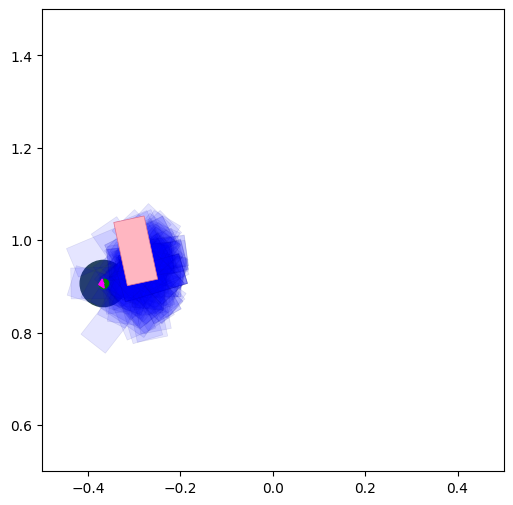

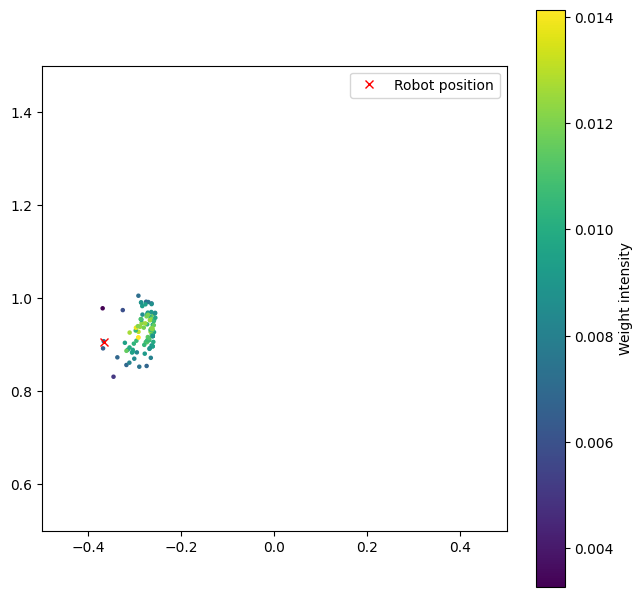

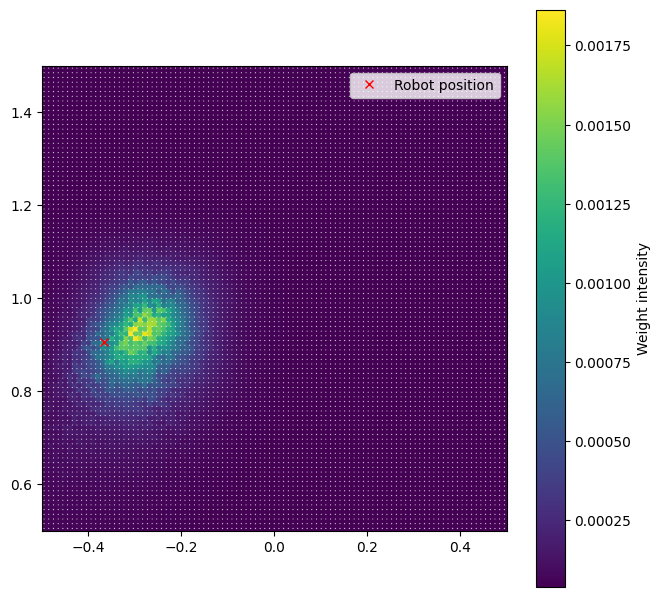

In [14]:
dpf.test(q_o_r_mins, q_o_r_maxs, means, stds, xy_only)